In [1]:
import pandas as pd
import numpy as np

# World Happiness Report 2023 — representative data
# Source: https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2023

df = pd.read_csv('/Users/sreenidhi/Downloads/world_happiness_2023.csv')
df.columns = ['Country','Region','Happiness_Score','GDP','Social_Support',
              'Life_Expectancy','Freedom','Generosity','Corruption']


print(f"Dataset: {len(df)} countries, {len(df.columns)} columns")
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: '/Users/sreenidhi/Downloads/world_happiness_2023.csv'

In [2]:
import plotly.express as px
import plotly.graph_objects as go

# Explore the dataset before you start
print("Regions in dataset:")
print(df['Region'].value_counts())
print("\nScore range:", df['Happiness_Score'].min(), "–", df['Happiness_Score'].max())
print("\nBottom 10 countries:")
print(df.nsmallest(10, 'Happiness_Score')[['Country','Region','Happiness_Score']])


Regions in dataset:
Region
Western Europe                  15
Latin America and Caribbean     13
Central and Eastern Europe       7
Sub-Saharan Africa               7
Middle East and North Africa     6
North America and ANZ            4
Southeast Asia                   4
South Asia                       4
East Asia                        3
Name: count, dtype: int64

Score range: 1.859 – 7.804

Bottom 10 countries:
        Country                        Region  Happiness_Score
60  Afghanistan                    South Asia            1.859
61      Lebanon  Middle East and North Africa            2.392
62     Zimbabwe            Sub-Saharan Africa            2.995
52     Ethiopia            Sub-Saharan Africa            3.564
53     Tanzania            Sub-Saharan Africa            3.698
48   Bangladesh                    South Asia            3.892
47        India                    South Asia            4.036
50        Kenya            Sub-Saharan Africa            4.112
54       Uganda

                         Region  Happiness_Score
5                    South Asia         3.618250
7            Sub-Saharan Africa         4.064714
3  Middle East and North Africa         4.943333
6                Southeast Asia         5.695250
2   Latin America and Caribbean         5.699000
1                     East Asia         5.966000
0    Central and Eastern Europe         6.338143
4         North America and ANZ         7.018250
8                Western Europe         7.085533


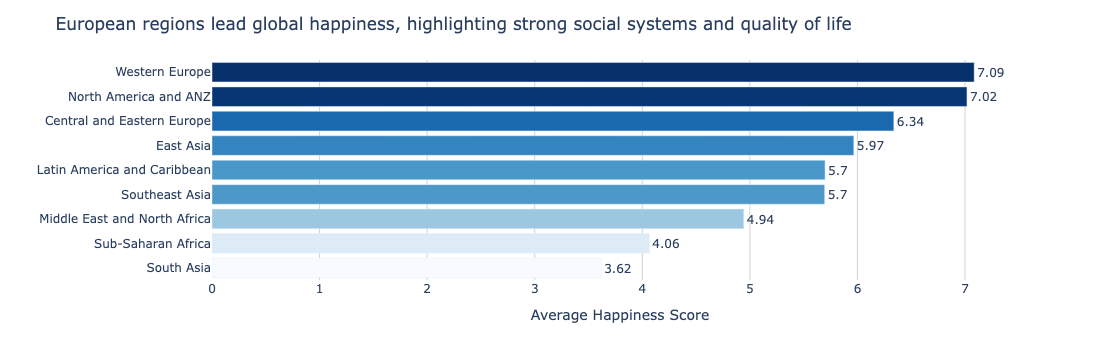

In [3]:
# Task 1: Regional comparison bar chart
# -------------------------------------

# Step 1: Compute average happiness score by region
region_avg = (df.groupby('Region')['Happiness_Score']
              .mean()
              .reset_index()
              .sort_values('Happiness_Score'))  # sort for horizontal bar

print(region_avg)

# Step 2: Build your chart
# YOUR CODE HERE

fig = px.bar(
    region_avg,
    x='Happiness_Score',
    y='Region',
    orientation='h',
    text=region_avg['Happiness_Score'].round(2),
    color='Happiness_Score',
    color_continuous_scale='Blues'
)

# Ensuring zero baseline
fig.update_xaxes(range=[0, region_avg['Happiness_Score'].max() + 0.5])

# Improve layout (professional look)
fig.update_layout(
    title='European regions lead global happiness, highlighting strong social systems and quality of life',
    xaxis_title='Average Happiness Score',
    yaxis_title='',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(size=12),
    coloraxis_showscale=False
)

# Clean gridlines
fig.update_xaxes(showgrid=True, gridcolor='lightgrey')
fig.update_yaxes(showgrid=False)

# Make text readable
fig.update_traces(textposition='outside')

fig.show()




Global average: 5.81


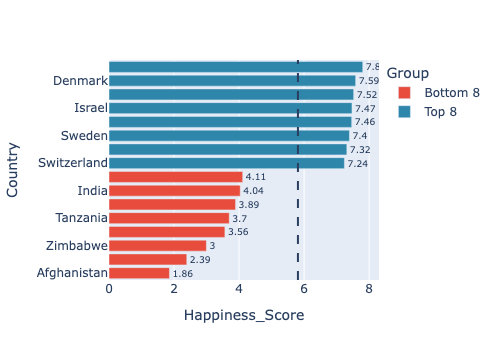

In [4]:
# Task 2: Top 8 vs. Bottom 8 contrast
# ------------------------------------

# Step 1: Get top and bottom countries
top8 = df.nlargest(8, 'Happiness_Score').copy()
top8['Group'] = 'Top 8'
bottom8 = df.nsmallest(8, 'Happiness_Score').copy()
bottom8['Group'] = 'Bottom 8'

combined = pd.concat([bottom8, top8]).sort_values('Happiness_Score')
global_avg = df['Happiness_Score'].mean()
print(f"Global average: {global_avg:.2f}")

# Step 2: Build your chart
# YOUR CODE HERE

fig = px.bar(
    combined,
    x='Happiness_Score',
    y='Country',
    orientation='h',
    text=combined['Happiness_Score'].round(2),
    color='Group',
    color_discrete_map={
        'Top 8': '#2E86AB',
        'Bottom 8': '#E74C3C'
    }
)

# zero baseline
fig.update_xaxes(range=[0, combined['Happiness_Score'].max() + 0.5])

# global average line
fig.add_vline(x=global_avg, line_dash="dash")

# show values
fig.update_traces(textposition='outside')

fig.show()